In [1]:
import datetime

from typing import Iterator

import numpy as np
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import shapely as shp
import hvplot.pandas
import matplotlib.pyplot as plt
import matplotlib.colors
import folium
import shapely



In [2]:
mmsi_a = 265550210
mmsi_b = 265410000

color_a = (0, 0.3, 0.3)
color_b = (0.3, 0, 0.3)
t_0 = datetime.datetime(2017, 7, 5, 19, 0, 0)
t_1 = datetime.datetime(2017, 7, 5, 19, 13, 55)


# we expect to find this as the closest point and interval of overlapping time window
expected = {
    "t": datetime.datetime(2017, 7, 5, 19, 8, 31),
    "p": shapely.Point(669670.780244901, 6397464.37325368),
    "q": shapely.Point(669566.587642144, 6397098.724455765),
    "t0_min": datetime.datetime(2017, 7, 5, 19, 0, 1), 
    "t1_max": datetime.datetime(2017, 7, 5, 19, 13, 53)
}

In [3]:
ais_gdf = gpd.read_file('../data/ais.gpkg')
ais_gdf["t"] = pd.to_datetime(ais_gdf["Timestamp"], format="%d/%m/%Y %H:%M:%S")
ais_gdf['t_min_t_0'] = (ais_gdf["t"] - t_0).dt.total_seconds()

ais_gdf = ais_gdf.to_crs('EPSG:32632')

In [4]:
ais_gdf = ais_gdf[
    np.logical_and.reduce([
        ais_gdf['MMSI'].isin([mmsi_a, mmsi_b]),
        ais_gdf['t'] >= t_0,
        ais_gdf['t'] < t_1
    ])
]


In [5]:
ais_gdf['traj_id'] = ais_gdf['MMSI']
ais_gdf['obj_id'] = ais_gdf['MMSI']
traj_collection = mpd.TrajectoryCollection(
    ais_gdf.set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)
traj_collection.add_speed(overwrite=True, units=('m', 's'))
traj_collection.add_direction(overwrite=True)


traj_a = traj_collection.get_trajectory(mmsi_a)
traj_b = traj_collection.get_trajectory(mmsi_b)


In [6]:
# create a variant in wgs84 to show a plot
traj_collection_wgs84 = mpd.TrajectoryCollection(
    ais_gdf.to_crs('EPSG:4326').set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)
# show trajectories with number of seconds since t_0
traj_collection_wgs84.hvplot(c='t_min_t_0', cmap='Blues')

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (t_min_t_0)
   .Points.I :Points   [Longitude,Latitude]   (t_min_t_0,triangle_angle)

In [7]:
variable_doc = """
    Results contain the following variables:
        p0, p1, q0, q1, t0, t1: input variables
        t: closest point of approach (datetime)  # KEEP
        t_tot: relative time in the interval when objects reach eachother 
        p: point at closest approach for object p 
        q: point at closest approach for object q 
        pq: line between p and q at closest approach # KEEP (so we only have one geometry)
        pv: vector of p
        qv: vector of q
        dv: difference between p and q vectors
        dv2: squared distance of p and q vectors
        dist: distance at cpa # KEEP
        dist2: squared distance at cpa
        status: string representing "converging" (t_tot < 0), "diverging" (t_tot > 1), "approaching"  0 < t_tot < 1, or "parallel" (dist2 == 0)
"""

def segments_cpa(
    p0: shapely.Point,
    p1: shapely.Point, 
    q0: shapely.Point, 
    q1: shapely.Point, 
    t0: datetime.datetime, 
    t1: datetime.datetime
) -> pd.Series:
    """
    Compute the closest point of approach (cpa) for a two pairs of points ((p0, p1), (q0, q1)) for time window (t0, t1)/

    """ + variable_doc

    # we follow the implementation of postgis
    # https://github.com/postgis/postgis/blob/9637dc369361ac118e1ad37da7a519dae9dfab5e/postgis/lwgeom_functions_temporal.c#L83
    p0_orig = p0
    p1_orig = p1
    q0_orig = q0
    q1_orig = q1
    
    
    # convert to vectors
    p0 = np.asarray(p0.coords)[0]
    p1 = np.asarray(p1.coords)[0]
    q0 = np.asarray(q0.coords)[0]
    q1 = np.asarray(q1.coords)[0]

    # compute the following
    # pv; /* velocity of p, aka u */
    # qv; /* velocity of q, aka v */
    # dv; /* velocity difference */
    # w0; /* vector between first points *# 
    
    # pv = (p1 - p0);
    pv = p1 - p0
    
    # qv = (q1 - q0);
    qv = q1 - q0
    
    # dv = pv - qv
    dv = pv - qv
    

    
    
    dv2 = np.dot(dv, dv).item()

    if (dv2 == 0.0):
        # /* Distance is the same at any time, we pick the earliest */
        # relative distance is similar we can't compute approach
        status = 'parallel'

        # Now for a bit of extra work
        # We have to return a similar series to what we return when we did find a cpa
        # We'll use the point, distance, time at t0 
        p=p0_orig
        q=q0_orig
        # compute distance at t0
        d_pq = np.asarray(p.coords)[0] - np.asarray(q.coords)[0]
        dist2 = np.dot(d_pq, d_pq).item()
        dist = dist2 ** 0.5
        
        pq = shapely.LineString([p0_orig, q0_orig])
        result = pd.Series(dict(
            p0=p0_orig,
            p1=p1_orig,
            q0=q0_orig,
            q1=q1_orig,
            t0=t0,
            t1=t1,
            t=t0, # start time
            t_tot=0, # 0 fraction (arbitrary)
            p=p0_orig,
            q=q0_orig,
            pq=pq,
            pv=pv, 
            qv=qv,
            dv=dv,
            dv2=dv2,
            dist=dist,
            dist2=dist2,
            status=status
        ))
        return result
    
    # /* Distance at any given time, with t0 */
    # p0 - q0
    w0 = p0 - q0
    w0
    
    # t = -DOT(w0, dv) / dv2;
    assert dv2 != 0, "dv2 should not be 0"

    
    t_tot = (-np.dot(w0, dv).item() / dv2)


    status = ''
    # t clipped when converging or diverging
    t = t_tot
    if t_tot > 1:
        # converging
        t = 1
        status = 'converging'
    elif t < 0.0:
        # diverging
        t = 0
        status = 'diverging'
    else:
        status = 'approaching'
    
    # Update p0 moving trajectory with velocity pv and time t
    # p0 += pv * t;
    # q0 += qv * t;

    # we'll create a separate variable (unlike the code in lwgeom) 
    p_coords = p0 + pv * t 
    q_coords = q0 + qv * t
    
    # p and q are the position at the cpa
    p = shapely.Point(*p_coords) 
    q = shapely.Point(*q_coords)
    
    # We can now also compute tcpa
    # t = t0 + (t1 - t0) * t;
    t = t0 + (t1 - t0) * t

    d_pq = np.asarray(p.coords)[0] - np.asarray(q.coords)[0]
    dist2 = np.dot(d_pq, d_pq).item()
    dist = dist2 ** 0.5

    pq = shapely.LineString([p, q])
    
    result = pd.Series(dict(
        p0=p0_orig,
        p1=p1_orig,
        q0=q0_orig,
        q1=q1_orig,
        t0=t0,
        t1=t1,        
        t=t,
        t_tot=t_tot,
        p=p,
        q=q,
        pq=pq,
        pv=pv,
        qv=qv,
        dv=dv,
        dv2=dv2,
        dist=dist, 
        dist2=dist2,
        status=status
    ))
    return result
    

In [8]:

def gen_cpa_segments(traj_a: mpd.Trajectory, traj_b: mpd.Trajectory) -> Iterator[pd.Series]:
    """
    Generate the closest point of approach variables for all time steps of trajectories a and b.

    """ + variable_doc

    mindist2 = np.finfo(np.double).max

    cpa = None

    # we follow the implementation of postgis
    # https://github.com/postgis/postgis/blob/9637dc369361ac118e1ad37da7a519dae9dfab5e/postgis/lwgeom_functions_temporal.c#L83
    # gbox is the bounding box in x,y,z,m
    # tmin = FP_MAX(gbox1.mmin, gbox2.mmin);
    # tmax = FP_MIN(gbox1.mmax, gbox2.mmax);    

    t_min = max(traj_a.get_start_time(), traj_b.get_start_time())
    t_max = min(traj_a.get_end_time(), traj_b.get_end_time())
    t_min, t_max
    
    
    # * Collect M values in common time range from inputs
    # nmvals in postgis
    t_ab = np.unique(np.sort(np.r_[traj_a.df.index, traj_b.df.index]))
    t_ab_intervals = np.c_[t_ab[:-1], t_ab[1:]]


    
    for interval in t_ab_intervals:
        
    
        t0, t1 = interval
    
        # determine p0, p1, q0, q1
    
        # seg = ptarray_locate_along_linear(l1->points, t0, &p0, 0);
        # seg = ptarray_locate_along_linear(l1->points, t1, &p1, seg);
        # seg = ptarray_locate_along_linear(l2->points, t0, &q0, 0);
        # seg = ptarray_locate_along_linear(l2->points, t1, &q1, seg);
        
        p0 = traj_a.interpolate_position_at(t0)
        p1 = traj_a.interpolate_position_at(t1)
        q0 = traj_b.interpolate_position_at(t0)
        q1 = traj_b.interpolate_position_at(t1)
    
        # t = segments_tcpa(&p0, &p1, &q0, &q1, t0, t1);
        cpa = segments_cpa(p0=p0, p1=p1, q0=q0, q1=q1, t0=t0, t1=t1)
        yield cpa


def min_cpa(traj_a: mpd.Trajectory, traj_b: mpd.Trajectory) -> pd.Series:
    """
    Generate the minimum closest point of approach over all time steps of trajectories a and b.
    
    """ + variable_doc
    
    min_dist = np.finfo(np.double).max 
    min_cpa = None
    for cpa in gen_cpa_segments(traj_a, traj_b):
        if cpa.dist < min_dist:
            min_dist = cpa.dist
            min_cpa = cpa
        
    return min_cpa
    
def cpa_segments(traj_a: mpd.Trajectory, traj_b: mpd.Trajectory) -> gpd.GeoDataFrame:
    """
    Generate a GeoDataFrame with all closest point of approach variables for all time steps of trajectories a and b.
    The geometry column is set to the pq linestring. The crs is reused from traj_a.
    
    """ + variable_doc

    cpas = []
    for cpa in gen_cpa_segments(traj_a, traj_b):
        cpas.append(cpa)
    result = gpd.GeoDataFrame(cpas, geometry='pq', crs=traj_a.crs)
    return result

In [9]:
cpa_df = cpa_segments(traj_a, traj_b) 
cpa = min_cpa(traj_a, traj_b)
cpa_df.head()

,p0,p1,q0,q1,t0,t1,t,t_tot,p,q,pq,pv,qv,dv,dv2,dist,dist2,status
0,POINT (669586.8317745987 6398147.291889774),POINT (669586.8317745987 6398147.291889774),POINT (671906.5556039494 6397620.620787336),POINT (671894.3171391091 6397616.421302897),2017-07-05 19:00:01,2017-07-05 19:00:04,2017-07-05 19:00:04,156.365937,POINT (669586.8317745987 6398147.291889774),POINT (671894.3171391091 6397616.421302897),"LINESTRING (669586.832 6398147.292, 671894.317...","[0.0, 0.0]","[-12.23846484022215, -4.199484438635409]","[12.23846484022215, 4.199484438635409]",167.415691,2367.765252,5.606312e+06,converging
1,POINT (669586.8317745987 6398147.291889774),POINT (669586.8317745987 6398147.291889774),POINT (671894.3171391091 6397616.421302897),POINT (671888.8415459155 6397614.627653751),2017-07-05 19:00:04,2017-07-05 19:00:05,2017-07-05 19:00:05,351.894656,POINT (669586.8317745987 6398147.291889774),POINT (671888.8415459155 6397614.627653751),"LINESTRING (669586.832 6398147.292, 671888.842...","[0.0, 0.0]","[-5.4755931936670095, -1.7936491463333368]","[5.4755931936670095, 1.7936491463333368]",33.199298,2362.833082,5.582980e+06,converging
2,POINT (669586.8317745987 6398147.291889774),POINT (669586.8317745987 6398147.291889774),POINT (671888.8415459155 6397614.627653751),POINT (671877.8903595282 6397611.040355458),2017-07-05 19:00:05,2017-07-05 19:00:07,2017-07-05 19:00:07,175.447328,POINT (669586.8317745987 6398147.291889774),POINT (671877.8903595282 6397611.040355458),"LINESTRING (669586.832 6398147.292, 671877.89 ...","[0.0, 0.0]","[-10.951186387217604, -3.5872982926666737]","[10.951186387217604, 3.5872982926666737]",132.797192,2352.980057,5.536515e+06,converging
3,POINT (669586.8317745987 6398147.291889774),POINT (669586.8317745987 6398147.291889774),POINT (671877.8903595282 6397611.040355458),POINT (671865.661311963 6397606.61842454),2017-07-05 19:00:07,2017-07-05 19:00:10,2017-07-05 19:00:10,151.660145,POINT (669586.8317745987 6398147.291889774),POINT (671865.661311963 6397606.61842454),"LINESTRING (669586.832 6398147.292, 671865.661...","[0.0, 0.0]","[-12.229047565255314, -4.4219309175387025]","[12.229047565255314, 4.4219309175387025]",169.103077,2342.091342,5.485392e+06,converging
4,POINT (669586.8317745987 6398147.291889774),POINT (669586.8317745987 6398147.291889774),POINT (671865.661311963 6397606.61842454),POINT (671853.6157465233 6397602.092872436),2017-07-05 19:00:10,2017-07-05 19:00:13,2017-07-05 19:00:13,151.005604,POINT (669586.8317745987 6398147.291889774),POINT (671853.6157465233 6397602.092872436),"LINESTRING (669586.832 6398147.292, 671853.616...","[0.0, 0.0]","[-12.045565439737402, -4.525552104227245]","[12.045565439737402, 4.525552104227245]",165.576269,2331.426933,5.435552e+06,converging


<Axes: >

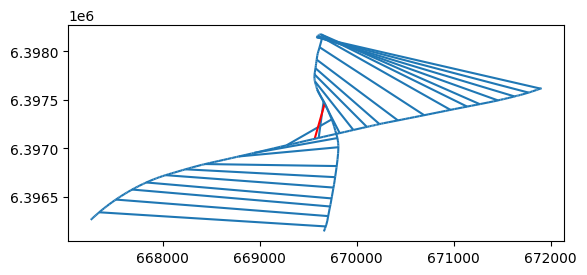

In [10]:
fig, ax = plt.subplots()

cpa_df[::10].plot(ax=ax)
gpd.GeoSeries(cpa['pq']).plot(ax=ax, color='red')
traj_a.plot(ax=ax)
traj_b.plot(ax=ax)